# LinUCB user context

In [1]:
import os
os.chdir('..')

In [2]:
os.getcwd()

'/Users/antonismand/Documents/work/Darelab/Github/SqlCompletions'

In [21]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from sqlcompletions import bandits
from sqlcompletions.evaluator import evaluate, run_n_tests
from sqlcompletions.sqlparser import schema
from sqlcompletions.processing import user_context
from matplotlib import pyplot as plt

db = schema()

def test_args(clause, k, features, n_components, constant=False):
    clauses = ["SELECT","FROM","WHERE"]
    n = db.n_tables if clause == 1 else db.n_columns

    log_file = f"/linucb/log_{features}_pca{n_components}"
    test_name = f"{clauses[features]} features, {n_components}"
    
    if constant:
        log_file += "_1"
        n_components += 1
        test_name += " + 1"

    log_file += "_th50.json"
    test_name += "PCs"
    return dict(
        clause=clause,
        bandit=bandits.LinUCB(
            alpha=0.3, n_arms=n, n_features=n_components
        ),
        top_k=k,
        db=db,
        log_file=log_file,
        pbar=False,
        max_iterations=None,
        skip_lines=0.1,
        color="r",
        name = test_name
    )

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## SELECT Features

CPU times: user 103 ms, sys: 136 ms, total: 239 ms
Wall time: 2min 57s


,Test,MAP@K,Execution Time
0,"SELECT features, 8 PCs",0.678073,2.34
1,"SELECT features, 14 PCs",0.709094,2.49
2,"FROM features, 14 PCs",0.669066,2.56
3,"FROM features, 14 PCs and 1 constant",0.662217,2.66
4,"SELECT features, 20 PCs",0.717735,2.94


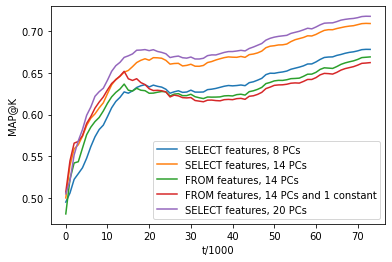

In [9]:
%%time
%matplotlib inline

k = 5

tests = []
tests.append([
        test_args(clause=0, k=k, features=0, n_components=8, constant=False),
        "SELECT features, 8 PCs",
    ])

tests.append([
        test_args(clause=0, k=k, features=0, n_components=14, constant=False),
        "SELECT features, 14 PCs",
    ])

tests.append([
        test_args(clause=0, k=k, features=0, n_components=20, constant=False),
        "SELECT features, 20 PCs",
    ])

tests.append([
        test_args(clause=0, k=k, features=1, n_components=14, constant=False),
        "FROM features, 14 PCs",
    ])

tests.append([
        test_args(clause=0, k=k, features=1, n_components=14, constant=True),
        "FROM features, 14 PCs and 1 constant",
    ])

results = run_n_tests(tests = tests, plot_name = "features_select").results
results

## FROM Features

CPU times: user 114 ms, sys: 68.8 ms, total: 183 ms
Wall time: 1min 34s


,Test,MAP@K,Execution Time
0,"FROM features, 6 PCs",0.642197,1.37
1,"FROM features, 10 PCs",0.668982,1.48
2,"FROM features, 10 PCs and 1 constant",0.673800,1.50
3,"FROM features, 14 PCs",0.687910,1.54
4,"FROM features, 14 PCs and 1 constant",0.693741,1.54


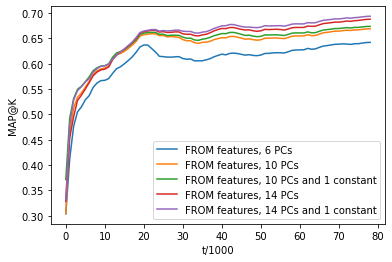

In [10]:
%%time
%matplotlib inline

k = 3

tests = []
tests.append([
        test_args(clause=1, k=k, features=1, n_components=6, constant=False),
        "FROM features, 6 PCs",
    ])

tests.append([
        test_args(clause=1, k=k, features=1, n_components=10, constant=False),
        "FROM features, 10 PCs",
    ])

tests.append([
        test_args(clause=1, k=k, features=1, n_components=14, constant=False),
        "FROM features, 14 PCs",
    ])

tests.append([
        test_args(clause=1, k=k, features=1, n_components=10, constant=True),
        "FROM features, 10 PCs and 1 constant",
    ])

tests.append([
        test_args(clause=1, k=k, features=1, n_components=14, constant=True),
        "FROM features, 14 PCs and 1 constant",
    ])

results = run_n_tests(tests = tests, plot_name = "features_from").results
results

## WHERE Clause

CPU times: user 102 ms, sys: 123 ms, total: 225 ms
Wall time: 1min 33s


,Test,MAP@K,Execution Time
0,"WHERE features, 6 PCs",0.649421,1.28
1,"WHERE features, 10 PCs",0.680764,1.42
2,"WHERE features, 14 PCs",0.700198,1.51
3,"FROM features, 14 PCs",0.608050,1.53
4,"WHERE features, 14 PCs and 1 constant",0.713828,1.54


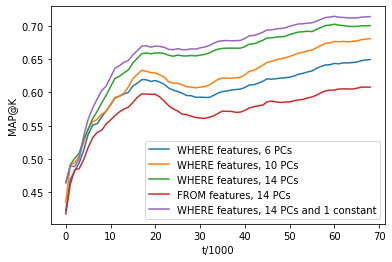

In [11]:
%%time
%matplotlib inline

k = 3

tests = []
tests.append([
        test_args(clause=2, k=k, features=2, n_components=6, constant=False),
        "WHERE features, 6 PCs",
    ])

tests.append([
        test_args(clause=2, k=k, features=2, n_components=10, constant=False),
        "WHERE features, 10 PCs",
    ])

tests.append([
        test_args(clause=2, k=k, features=2, n_components=14, constant=False),
        "WHERE features, 14 PCs",
    ])

tests.append([
        test_args(clause=2, k=k, features=2, n_components=14, constant=True),
        "WHERE features, 14 PCs and 1 constant",
    ])

tests.append([
        test_args(clause=2, k=k, features=1, n_components=14, constant=False),
        "FROM features, 14 PCs",
    ])

results = run_n_tests(tests = tests, plot_name = "features_where").results
results

,Test,MAP@K,Execution Time
1,"SELECT features, 14 + 1PCs",0.69,1.1
0,"SELECT features, 14 + 1PCs",0.66,1.1


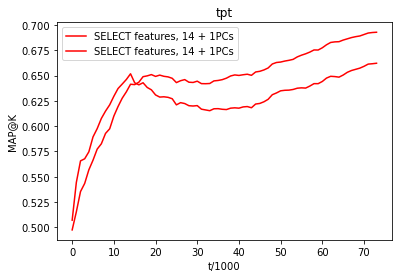

In [23]:

k = 5

tests = []
tests.append(
        test_args(clause=0, k=k, features=0, n_components=14, constant=True),
    )

tests.append(
        test_args(clause=0, k=k, features=1, n_components=14, constant=True),
    )


results = run_n_tests(tests = tests, plot_name = "tpt").results
results
